In [2]:
import matplotlib.pyplot as plt 
import tensorflow as tf
from keras.layers import *
from keras.models import Sequential
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import warnings
warnings.filterwarnings('ignore')

# read data

In [3]:
train_path = r"P:\Covid19-dataset\train"
test_path = r"P:\Covid19-dataset\test"

In [4]:
image_class = os.listdir(train_path)

In [5]:
image_class

['Covid', 'Normal', 'Viral Pneumonia']

# data visualization

In [6]:
def plot_image(image_class):
    plt.figure(figsize = (12,12))
    for i , category in enumerate(image_class):
        
        image_path = train_path + '/' + category
        image_in_folder = os.listdir(image_path)
        
        first_image = image_in_folder[0]
        first_image_path = image_path + "/" + first_image
        
        img = image.load_img(first_image_path)
        image_array = image.img_to_array(img)/255 #Converts it into a normalized array,suitable for display.
        
        plt.subplot(1,3, i+1)
        plt.imshow(image_array)
        plt.title(category)
        plt.axis('off')
        plt.show()

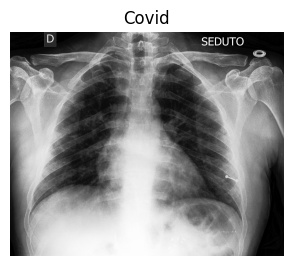

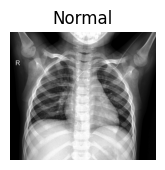

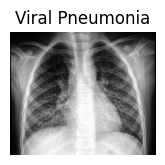

In [7]:
plot_image(image_class)

# data preprocessing

In [8]:
data_generator = ImageDataGenerator(rescale = 1 / 255)

In [9]:
#It's often used to preprocess and augment image datasets for training models.
#The number of samples/images processed together in one pass(forward and backward)is called the batch size.
# train data
train_data = data_generator.flow_from_directory(train_path ,
                                                target_size = (224 , 224),
                                                batch_size = 16) # Number of images per batch

Found 251 images belonging to 3 classes.


In [10]:
# test data
test_data = data_generator.flow_from_directory(test_path ,
                                                target_size = (224 , 224),
                                                batch_size = 16)
                     

Found 66 images belonging to 3 classes.


# model building

In [11]:
# model building
# An API (Application Programming Interface) i
cnn_model = Sequential()
# add conv layer with filter , kernel_size , activationand and input shape 
cnn_model.add(Conv2D(filters = 32 , kernel_size = 3, padding = 'same' , activation = 'relu' , input_shape = [224 , 224 , 3]))

# add max pooling layer
cnn_model.add(MaxPooling2D(pool_size = (2,2)))

# add conv layer with filter , kernel_size , activationand and input shape 
cnn_model.add(Conv2D(filters = 64 , kernel_size = 3, padding = 'same' , activation = 'relu'))

# add max pooling layer
cnn_model.add(MaxPooling2D())

# add conv layer with filter , kernel_size , activationand and input shape 
cnn_model.add(Conv2D(filters = 128 , kernel_size = 3, padding = 'same' , activation = 'relu'))

# add max pooling layer
cnn_model.add(MaxPooling2D())

# add flatten layer
cnn_model.add(Flatten())
# fully connected layer
cnn_model.add(Dense(128 , activation = 'relu'))
cnn_model.add(Dense(128 , activation = 'relu'))

# output layer
cnn_model.add(Dense(3 , activation = 'softmax'))

#  compile model

In [12]:
cnn_model.compile(optimizer = 'adam' ,  loss = 'categorical_crossentropy' , metrics = ['accuracy'])

# model fitting

In [13]:
model_history = cnn_model.fit(train_data, epochs = 5 , validation_data = test_data)


Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 582ms/step - accuracy: 0.5031 - loss: 1.8245 - val_accuracy: 0.7727 - val_loss: 0.7145
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 565ms/step - accuracy: 0.8372 - loss: 0.4297 - val_accuracy: 0.6667 - val_loss: 0.7239
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 554ms/step - accuracy: 0.8527 - loss: 0.3287 - val_accuracy: 0.7727 - val_loss: 0.4799
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 524ms/step - accuracy: 0.9214 - loss: 0.2060 - val_accuracy: 0.8182 - val_loss: 0.4467
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 519ms/step - accuracy: 0.9433 - loss: 0.1957 - val_accuracy: 0.8333 - val_loss: 0.4347


## model performance visualization

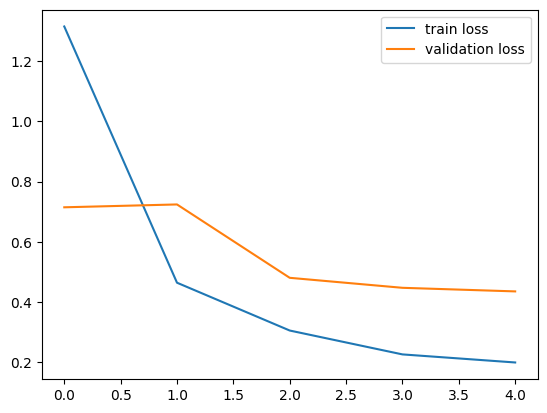

In [14]:
plt.plot(model_history.history['loss'] , label = 'train loss')
plt.plot(model_history.history['val_loss'] , label = 'validation loss')
plt.legend()
plt.show()

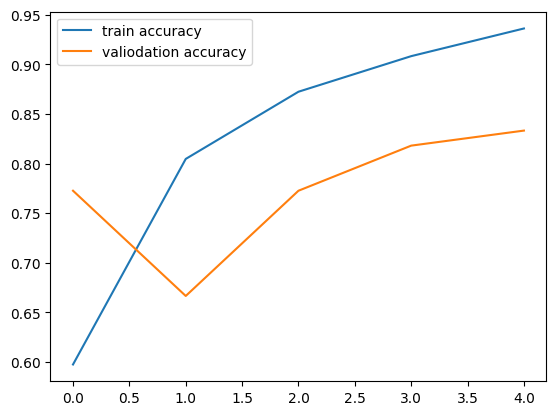

In [15]:
plt.plot(model_history.history['accuracy'] , label = 'train accuracy')
plt.plot(model_history.history['val_accuracy'] , label  = 'valiodation accuracy')
plt.legend()
plt.show()

# model evaluation

In [16]:
cnn_model.evaluate(test_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.7977 - loss: 0.5298


[0.4347413182258606, 0.8333333134651184]

In [17]:
cnn_model.evaluate(train_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.9592 - loss: 0.0861


[0.09835287183523178, 0.9601593613624573]

# predict new image

In [18]:
testing_image = r"P:\Covid19-dataset\test\Covid\096.png"

In [19]:
class_map = dict([value , key]for key,value in train_data.class_indices.items())
class_map

{0: 'Covid', 1: 'Normal', 2: 'Viral Pneumonia'}

In [20]:
import numpy as np
def predict_image(testing_image , actual_label):

    # load & prerpocessing image
    test_image = image.load_img(testing_image , target_size = (224 , 224))
    test_img_arr  = image.img_to_array(test_image)/ 255
    test_img_input = test_img_arr.reshape((1 , test_img_arr.shape[0] ,  test_img_arr.shape[1] ,  test_img_arr.shape[2]))

   # make prediction
    predicted_class = np.argmax(cnn_model.predict(test_img_input))
    predicted_img = class_map[predicted_class]

    plt.figure(figsize = (4,4))
    plt.imshow(test_img_arr)
    plt.title('actual label : {} ,predicted label : {}'.format(actual_label, predicted_img))
    plt.grid()
    plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


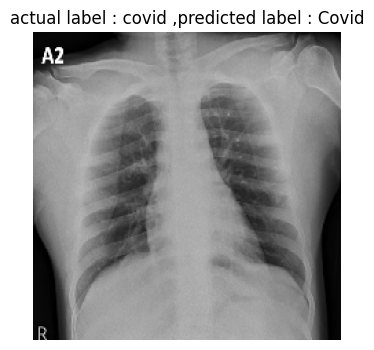

In [21]:
predict_image(testing_image , actual_label = 'covid')

In [22]:
cnn_model.save("covid19_model.keras")